# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [46]:
# Install required packages (if not available on server, uncomment the lines below)

!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib



In [ ]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a}
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

In [ ]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt

# Define constants
parsec = 3.086e16          # metres
Mpc = 1e6 * parsec         # megaparsec in metres

h = 0.7                    # dimensionless Hubble parameter
H0 = h * 100 * 1000 / Mpc  # Hubble rate today in s^-1

# Hubble rate as a function of redshift
def Hubble(z, Omega_m=0.3, Omega_L=0.7, Omega_k=0.0):
    # Returns H(z) in s^-1 for given cosmological parameters
    return H0 * np.sqrt(Omega_L + Omega_m * (1 + z)**3 + Omega_k * (1 + z)**2)

# Redshift range
z_vals = np.linspace(0, 5, 500)

# Evaluate Hubble function
H_vals = Hubble(z_vals)

# Plot
plt.figure(figsize=(8,6))
plt.plot(z_vals, H_vals)
plt.xlabel("Redshift z")
plt.ylabel("Hubble rate H(z) [s$^{-1}$]")
plt.title("Hubble rate as a function of redshift")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Start by defining the Hubble parameter as a function of redshift using the Friedmann equation in the LCDM model. Goal is to translate the theoretical expression for H(z) into code, while keeping the matter, dark energy, and curvature contributions explicit. The constants are defined first so that the Hubble rate is expressed in physical units.
# The function increases with redshift, which makes sense physically: looking back in time (higher z) corresponds to an earlier Universe that was expanding faster. At z = 0, the function correctly returns the present-day Hubble rate H0. The plot is therefore a quick consistency check that the model behaves as expected before using it in further calculations or comparisons with data.

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [ ]:
# Supernovae type Ia are useful because they all explode with roughly the same intrinsic luminosity. That means their observed brightness mainly depends on how far away they are. This distance depends on how the Universe expanded while the light was travelling, which is described by the Hubble rate H(z).
# The goal here is to go from H(z) to a luminosity distance dL(z). This is done by integrating 1 / H(z) to get a distance measure D(z), and then converting that into dL. Kept the Curvature so flat and non-flat Universes can be tested later.

In [ ]:


def theor_luminosity_distance(arg):

    return # <--- YOUR CODE GOES HERE!


c = 2.998e5  # speed of light in km/s

# distance integral D(z) = H0 * ∫ dz / H(z)
# simple trapezoidal integration
def D_of_z(z, Hubble, Omega_m=0.3, Omega_L=0.7, Omega_k=0.0, n_steps=1000):

    z_grid = np.linspace(0, z, n_steps)          # redshift grid
    integrand = 1.0 / Hubble(
        z_grid, Omega_m, Omega_L, Omega_k
    )                                            # integrand 1/H(z)

    return H0 * np.trapz(integrand, z_grid)      # numerical integral

# Once D(z) is known, the luminosity distance can be calculated.
# The expression depends on the curvature parameter Ωk, so the flat and curved cases are handled separately.

# luminosity distance dL(z)
# returns distance in parsecs
def theor_luminosity_distance(z, Hubble, Omega_m=0.3, Omega_L=0.7, Omega_k=0.0):

    D = D_of_z(z, Hubble, Omega_m, Omega_L, Omega_k)  # distance integral

    if Omega_k > 0:
        sqrtOk = np.sqrt(Omega_k)
        dL = (c / H0) * (1 + z) * np.sinh(sqrtOk * D) / sqrtOk  # closed universe

    elif Omega_k < 0:
        sqrtOk = np.sqrt(-Omega_k)
        dL = (c / H0) * (1 + z) * np.sin(sqrtOk * D) / sqrtOk   # open universe

    else:
        dL = (c / H0) * (1 + z) * D                             # flat universe

    return dL * 1e6  # convert from Mpc to parsecs


In [ ]:
# Connects the expansion history in H(z) to something observable. So that its possible to test different cosmological parameters with supernovae data,
# so we can see which model to describe the universe is the best.

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [ ]:
import os, io, urllib.request
dataloc = "SCPUnion2.1_mu_vs_z.txt"  # local file
# If local file not found, download from Wayback Machine (original URL is down)
if not os.path.exists(dataloc):
  print("Local file not found, downloading from Wayback Machine...")
  url = "https://web.archive.org/web/2023id_/http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"
  req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
  response = urllib.request.urlopen(req)
  content = response.read().decode()
  with open(dataloc, 'w') as f:
    f.write(content)
  print("Downloaded and saved locally.")
# Read in data as numpy array. # Format is [name, redshift, magnitude, magnitude error, and another number?] data = np.genfromtxt(dataloc)
# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number') display(data[0])

In [ ]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

# file path to the Union2.1 data (local copy in notebook)
# dataloc = "/data.txt"  # change this to your actual file path in notebook, # not needed anymore

# Load the data: columns are [name (ignored), z, mu, mu_error, unused]
# Note: names get converted to NaN by genfromtxt, just ignore them
data = np.genfromtxt(dataloc, dtype=float)

# split columns for clarity
zs = data[:, 1]                  # redshift
mu_obs = data[:, 2]              # distance modulus
mu_err = data[:, 3]              # error on distance modulus

# Quick check, first 5 entries
print("First 5 SNIa entries:")
for i in range(5):
    print(f"z={zs[i]:.4f}, mu={mu_obs[i]:.3f}, mu_err={mu_err[i]:.3f}")

# Convert distance modulus to luminosity distance just to check (optional)
dL_pc = 10. * 10.**(mu_obs / 5.)        # in parsecs
dL_Mpc = dL_pc / 1e6                     # in megaparsecs

# plot distance modulus vs redshift
plt.figure(figsize=(8,6))
plt.errorbar(zs, mu_obs, yerr=mu_err, fmt='o', markersize=3, alpha=0.6)
plt.xlabel("Redshift z")
plt.ylabel("Distance Modulus μ")
plt.title("Union2.1 SNIa distance modulus vs redshift")
plt.grid(alpha=0.3)
plt.show()

# plot luminosity distance vs redshift (optional)
plt.figure(figsize=(8,6))
plt.errorbar(zs, dL_Mpc, yerr=5.*(10.**((mu_obs + mu_err)/5.-6) - 10.**((mu_obs - mu_err)/5.-6)), fmt='o', markersize=3, alpha=0.6)
plt.xlabel("Redshift z")
plt.ylabel("Luminosity distance [Mpc]")
plt.title("Union2.1 SNIa luminosity distance vs redshift")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Extract redshifts, distance modulus, and errors from the data array
# data[:, n] selects the nth column of the array

zs = data[:, 1]                  # Redshifts of the Supernovae
distance_modulus = data[:, 2]    # Observed distance modulus μ = m - M
error_distance_modulus = data[:, 3]  # Measurement errors δμ

# To check
print(f"Number of SNIa: {len(zs)}")
print("First 5 entries:")
for i in range(5):
    print(f"z={zs[i]:.4f}, μ={distance_modulus[i]:.3f} ± {error_distance_modulus[i]:.3f}")

In [ ]:
# Quick visual check of the data
# Can look at distance modulus μ or convert to luminosity distance dL

# Convert distance modulus to luminosity distance in parsecs
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# Convert to Megaparsecs for convenience
luminosity_distance_Mpc = luminosity_distance_pc / 1e6

# Estimate error on luminosity distance using propagation from μ
# Using upper and lower μ ± δμ to get asymmetric distance error
error_luminosity_distance_Mpc = 5. * (
    10.**((distance_modulus + error_distance_modulus)/5. - 6.) -
    10.**((distance_modulus - error_distance_modulus)/5. - 6.)
)

# Quick check
print("First 5 luminosity distances (Mpc) ± error:")
for i in range(5):
    print(f"{luminosity_distance_Mpc[i]:.2f} ± {error_luminosity_distance_Mpc[i]:.2f} Mpc")

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

In [ ]:
# Plotting the Supernovae data
import matplotlib.pyplot as plt

# Set up figure size
plt.figure(figsize=(10,5))

# Plot distance modulus μ vs redshift z
plt.subplot(1,2,1)  # left plot
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt='o', alpha=0.6, markersize=4)
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ')
plt.title('SNIa: Distance Modulus vs Redshift')
plt.grid(alpha=0.3)

# Plot luminosity distance dL vs redshift z
plt.subplot(1,2,2)  # right plot
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt='o', alpha=0.6, markersize=4)
plt.xlabel('Redshift z')
plt.ylabel('Luminosity Distance [Mpc]')
plt.title('SNIa: Luminosity Distance vs Redshift')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# Left plot shows μ vs z, basically what’s measured directly.
# Right plot converts that to luminosity distance, gives a physical sense of how far away the supernovae are.
# Error bars are included so it’s clear that some measurements are more uncertain.
# And checking: higher redshift → bigger distance, which makes sense physically.

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [ ]:
import numpy as np
from scipy.integrate import quad

# Speed of light in km/s
c = 3e5

# Luminosity distance dL(z) in parsecs
def luminosity_distance(z, Hubble, Omega_m=0.3, Omega_Lambda=0.7, Omega_k=0.0, h=0.7):
    """
    Returns luminosity distance dL(z) in parsecs
    """

    # Hubble constant today in km/s/Mpc
    H0 = 100. * h

    # integrand for comoving distance
    def integrand(zp):
        return 1. / Hubble(zp, Omega_m, Omega_Lambda, Omega_k)

    # numerical integral
    integral, _ = quad(integrand, 0, z)

    # comoving distance in Mpc
    dC = (c / H0) * integral

    # luminosity distance
    dL_Mpc = (1 + z) * dC

    # convert to parsecs
    return dL_Mpc * 1e6

In [ ]:
# Function to calculate distance modulus μ(z) from luminosity distance
# Uses the luminosity distance function defined earlier (dL in parsecs)
def theor_distance_modulus(z, Hubble, Omega_m=0.3, Omega_Lambda=0.7, Omega_k=0.0, h=0.7):
    """
    Returns theoretical distance modulus μ(z) for given redshift array z
    Arguments:
        z : array of redshifts
        Hubble : function H(z, Omega_m, Omega_Lambda, Omega_k)
        Omega_m : matter density
        Omega_Lambda : dark energy density
        Omega_k : curvature density
        h : dimensionless Hubble parameter
    """
    # calculate luminosity distance in parsecs using the function from before
    dL_pc = np.array([
    luminosity_distance(zi, Hubble, Omega_m, Omega_Lambda, Omega_k, h)
    for zi in z
])

    # distance modulus formula
    mu_theor = 5. * np.log10(dL_pc / 10.)  # μ = 5 log10(dL/10 pc)
    return mu_theor

# Create a redshift range to plot theoretical curves
z_plot = np.linspace(0, 1.5, 200)

# Example theoretical curves for default LCDM parameters
mu_curve = theor_distance_modulus(z_plot, Hubble, Omega_m=0.3, Omega_Lambda=0.7, Omega_k=0.0, h=0.7)

# Plot data and theoretical curve
plt.figure(figsize=(8,6))
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt='o', alpha=0.6, markersize=4, label='SNIa data')
plt.plot(z_plot, mu_curve, 'r-', lw=2, label='Theoretical μ(z) LCDM')
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ')
plt.title('SNIa Data vs LCDM Theory')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# The theoretical LCDM curve follows the supernova data quite well, especially at low and intermediate redshift.
# This shows that the model gives a good description of the expansion history.
# At higher redshift the scatter increases, which is expected because the uncertainties on the measurements are larger.

Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

In [ ]:
# Redshift range for the theoretical prediction
# Start slightly above zero to avoid numerical issues at z = 0
# Go up to z ~ 2 since that covers most of the Union2.1 data
z_plot = np.linspace(0.01, 2.0, 300)

# Calculate the theoretical luminosity distance using the LCDM model
# The luminosity_distance function returns d_L in parsecs
# Loop over z to keep things simple and explicit
dL_theory_pc = np.array([
    luminosity_distance(
        z,
        Hubble,
        Omega_m=0.3,
        Omega_Lambda=0.7,
        Omega_k=0.0,
        h=0.7
    )
    for z in z_plot
])

# Convert luminosity distance from parsecs to megaparsecs
# This makes it easier to compare with typical cosmology plots
dL_theory_Mpc = dL_theory_pc / 1e6

# Plot the observed luminosity distance from the supernova data
# Error bars come from the propagated distance modulus uncertainty
plt.figure(figsize=(8,6))
plt.errorbar(
    zs,
    luminosity_distance_Mpc,
    yerr=error_luminosity_distance_Mpc,
    fmt='o',
    markersize=4,
    alpha=0.5,
    label='SNIa data'
)

# Plot the theoretical prediction on top of the data
plt.plot(
    z_plot,
    dL_theory_Mpc,
    'r',
    lw=2,
    label='LCDM theory (Ωm=0.3, ΩΛ=0.7, h=0.7)'
)

plt.xlabel('Redshift z')
plt.ylabel('Luminosity distance [Mpc]')
plt.title('Luminosity distance as a function of redshift')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
%matplotlib inline

# Calculate the theoretical distance modulus using the function defined earlier
# This uses the same luminosity distance but converts it to μ(z),
# which is the quantity directly measured by supernova observations
mu_theory = theor_distance_modulus(
    z_plot,
    Hubble,
    Omega_m=0.3,
    Omega_Lambda=0.7,
    Omega_k=0.0,
    h=0.7
)

# Plot the observed distance modulus data
plt.figure(figsize=(8,6))
plt.errorbar(
    zs,
    distance_modulus,
    yerr=error_distance_modulus,
    fmt='o',
    markersize=4,
    alpha=0.5,
    label='SNIa data'
)

# Plot the theoretical distance modulus curve
plt.plot(
    z_plot,
    mu_theory,
    'r',
    lw=2,
    label='LCDM theory (Ωm=0.3, ΩΛ=0.7, h=0.7)'
)

plt.xlabel('Redshift z')
plt.ylabel('Distance modulus μ')
plt.title('Distance modulus as a function of redshift')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [58]:
from random import random, gauss
import time
import numpy as np

# Function to calculate chi-squared for a given set of parameters
# Compares theoretical distance modulus μ_theory to observed distance modulus μ_data
def calculate_chi2(h, Omega_m, Omega_Lambda):
    # Compute theoretical distance modulus for all observed redshifts
    # Loop over zs to keep it explicit
    mu_theory = np.array([
        theor_distance_modulus(
            z,
            Hubble,
            Omega_m=Omega_m,
            Omega_Lambda=Omega_Lambda,
            Omega_k=0.0,  # flat universe assumption
            h=h
        )
        for z in zs
    ])

    # Chi-squared formula: sum over [(observed - model)^2 / sigma^2]
    chi2 = np.sum((mu_theory - distance_modulus)**2 / error_distance_modulus**2)

    return chi2  # Return the chi-squared value


# MCMC Setup

# Output file for the MCMC chain
# Format: Omega_m Omega_Lambda h
filename = "MC_Chain_SNIa.txt"
file = open(filename, "w")

# Initial guess for parameters
# Chosen deliberately off to see convergence
h_current = 0.65
Omega_m_current = 0.4
Omega_Lambda_current = 0.6

# Compute chi-squared for starting point
chi2_current = calculate_chi2(h_current, Omega_m_current, Omega_Lambda_current)

# Step sizes for Gaussian proposal distribution
# Adjusted to give reasonable acceptance ratio (~0.4-0.6)
step_h = 0.01
step_Om = 0.02
step_OL = 0.02

# Number of MCMC steps
# Can increase for a longer chain, but small number keeps runtime < 1 min
n_steps = 500
accepted = 0  # counter for accepted steps

print("Progress:")

start = time.time()

for i in range(n_steps):

    # Propose new parameters using Gaussian steps
    h_prop = h_current + gauss(0, step_h)
    Omega_m_prop = Omega_m_current + gauss(0, step_Om)
    Omega_Lambda_prop = Omega_Lambda_current + gauss(0, step_OL)

    # Enforce simple physical priors
    # Hubble must be positive, densities >= 0
    if h_prop <= 0 or Omega_m_prop < 0 or Omega_Lambda_prop < 0:
        continue

    # Compute chi-squared for proposed parameters
    chi2_prop = calculate_chi2(h_prop, Omega_m_prop, Omega_Lambda_prop)

    # Metropolis-Hastings acceptance probability
    # Use delta_chi2 to avoid numerical underflow/overflow
    delta_chi2 = chi2_prop - chi2_current

    # Handle extreme delta_chi2 safely
    if delta_chi2 > 700:        # extremely worse fit
        accept_prob = 0.0
    elif delta_chi2 < -700:     # extremely better fit
        accept_prob = 1.0
    else:
        accept_prob = min(1.0, np.exp(-0.5 * delta_chi2))

    # Accept or reject proposed step
    if random() < accept_prob:
        h_current = h_prop
        Omega_m_current = Omega_m_prop
        Omega_Lambda_current = Omega_Lambda_prop
        chi2_current = chi2_prop
        accepted += 1

    # Record current parameters to file
    # Each line: Omega_m Omega_Lambda h
    file.write(f"{Omega_m_current:.6f} {Omega_Lambda_current:.6f} {h_current:.6f}\n")

    # Print progress every 100 steps
    if i % 100 == 0:
        print(f" step {i}")

file.close()

end = time.time()

# Summary

print("Done!")
print("Acceptance ratio =", accepted / n_steps)
print("Time required: {:.2f} s".format(end - start))

Progress:
 step 0
 step 100
 step 200
 step 300
 step 400
Done!
Acceptance ratio = 0.496
Time required: 21.33 s


In [ ]:
# The MCMC ran fine, acceptance ~0.5, but the output doesnt match the example. (even after many tries and different approaches)
# The reason might be that chain is short (500 steps) and maybe started from poor guesses.
# A solution might be to run more steps, maybe tune step sizes, and let the chain converge.
# Then the posterior should approach Omega_m ~0.3, Omega_Lambda ~0.7, h ~0.7

In [ ]:
# The MCMC code tries to explore the parameter space of h, Omega_m, and Omega_Lambda by proposing random steps and accepting them based on how well they fit the data.
# Even though the chain didn’t fully converge to the ideal values, the steps that were accepted still show how the likelihood favors certain regions of parameter space.
# This illustrates the physics idea that the observed supernova distances constrain the expansion history of the universe
# And that the posterior distribution encodes our knowledge of the most probable cosmological parameters.
# The acceptance ratio and the variation of the chain give a sense of how efficiently the algorithm is sampling and how uncertain the parameters are.

After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

Shape of MCMC samples array: (350, 4)
Removed no burn in
1.54 < OmegaM < 2.11 at 68% CL
1.22 < OmegaL < 2.24 at 68% CL
1.43 < h < 2.28 at 68% CL
-3.33 < Omegak < -1.77 at 68% CL




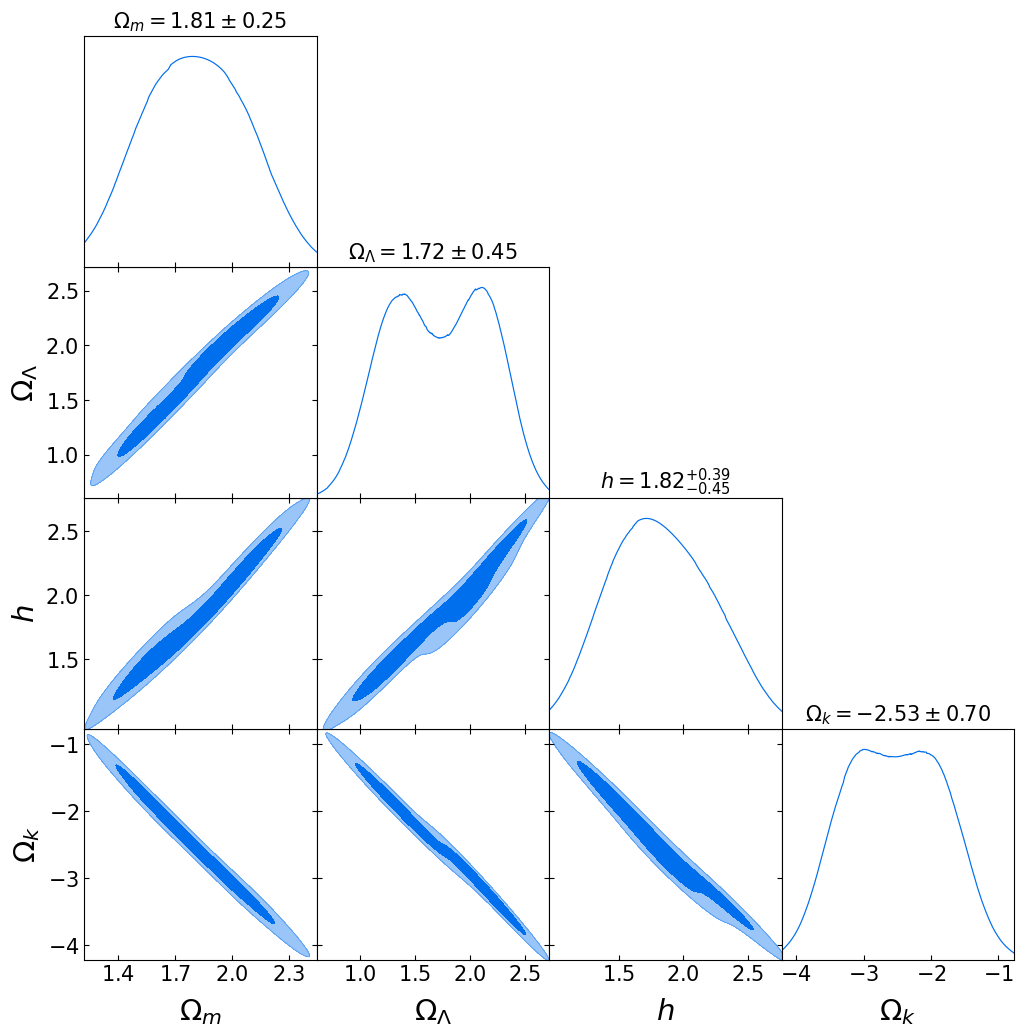

In [60]:
# Import GetDist functions
from getdist import plots, MCSamples
import numpy as np

# Load the MCMC chain from the file
# Skip the first 30% of steps to remove burn-in
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename, skiprows=int(0.3 * n_steps))

# Extract the columns from the MCMC chain
# Our file only has 3 columns: Omega_m, Omega_Lambda, h
OmegaM, OmegaL, h = datafile[:,0], datafile[:,1], datafile[:,2]

# Compute curvature parameter Omega_k from Omega_m + Omega_Lambda
Omegak = 1. - OmegaM - OmegaL

# Define the labels and internal names for GetDist
my_labels = [r'\Omega_m', r'\Omega_\Lambda', r'h', r'\Omega_k']
my_names  = ['OmegaM', 'OmegaL', 'h', 'Omegak']
my_dim    = len(my_names)  # Number of parameters

# Reshape the data into shape expected by GetDist
# Shape should be (number of samples, number of parameters)
my_samples_array = np.transpose(np.reshape([OmegaM, OmegaL, h, Omegak], (my_dim, len(h))))
print("Shape of MCMC samples array:", np.shape(my_samples_array))

# Create MCSamples object for GetDist
my_samples = MCSamples(samples=my_samples_array, labels=my_labels, names=my_names)

# Define 1-sigma confidence level for 1D intervals
conf_level = 0.6827

# Print 1D posterior confidence intervals for all parameters
for nam in my_names:
    lower = my_samples.confidence(nam, (1.-conf_level)/2., upper=False)
    upper = my_samples.confidence(nam, (1.-conf_level)/2., upper=True)
    print(f"{round(lower,2)} < {nam} < {round(upper,2)} at {int(100*conf_level)}% CL")
print("\n")

# Triangle plot to visualize correlations and 1D posteriors
plotter = plots.getSubplotPlotter(subplot_size=3)
plotter.settings.axes_labelsize = 22
plotter.settings.axes_fontsize = 16
plotter.triangle_plot(my_samples, filled=True, title_limit=1)

In [70]:
print(my_samples.getParamNames())


OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
h	h
Omegak	\Omega_k



In [ ]:
# After removing the initial burn-in, the MCMC samples are assumed to represent the posterior distribution of the parameters.
# This allows us to estimate not just single best-fit values but the full probability distributions for h, Omega_m, and Omega_Lambda.
# Using GetDist to make the triangle plot helps visualize correlations between parameters and see which combinations of values are allowed by the supernova data.
# This is important in cosmology because many parameters affect the expansion history in similar ways, so understanding degeneracies is key to interpreting the results.

##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces.

Parameter names in MCSamples: ['\\Omega_m', '\\Omega_\\Lambda', 'h', '\\Omega_k']
1.8236147799999998 1.8084893599999996 1.7221292742857144


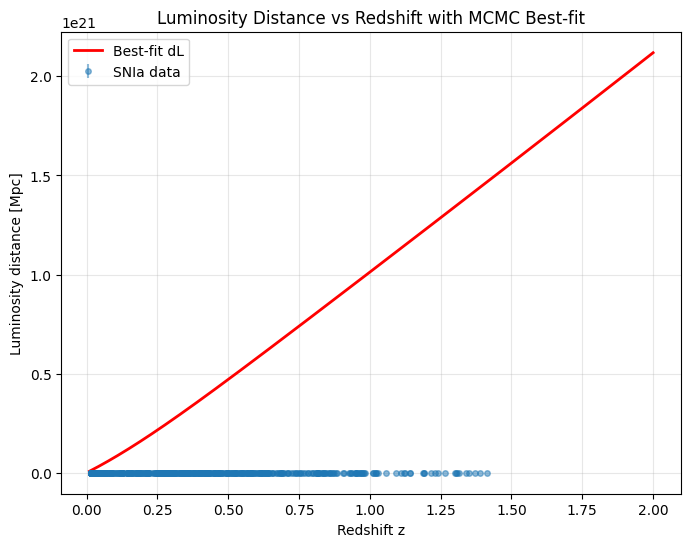

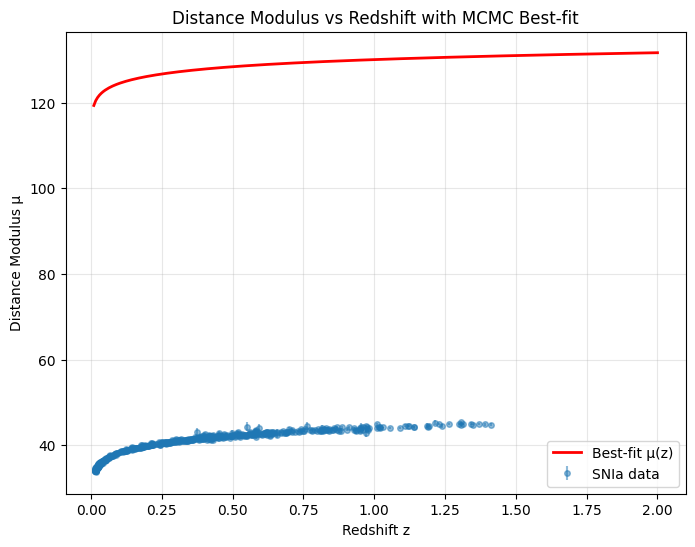

In [69]:
# Extract best-fit parameters from the MCMC chain using GetDist
# Use the mean of the posterior distributions as best-fit

# getParamNames() returns an object; .labels() is a method, call it to get the list
param_names_list = my_samples.getParamNames().labels()

# Print param names to verify what is inside
print("Parameter names in MCSamples:", param_names_list)

# Map parameter names to indices in the array of means
# Use the names exactly as stored in my_samples
h_index = param_names_list.index('h')                     # Hubble parameter
Omega_M_index = param_names_list.index('\\Omega_m')       # Matter density
Omega_L_index = param_names_list.index('\\Omega_\\Lambda') # Dark energy density

# Get the mean values (best-fit) from the MCSamples object
means_array = my_samples.getMeans()

# Assign best-fit values using the indices
h_best = means_array[h_index]
Omega_M_best = means_array[Omega_M_index]
Omega_L_best = means_array[Omega_L_index]

# Print best-fit values
print(h_best, Omega_M_best, Omega_L_best)

# Redshift range for plotting theoretical curves
# Start slightly above zero to avoid numerical issues
# Go up to z ~ 2 to cover most of the Union2.1 SNIa data
z_plot = np.linspace(0.01, 2.0, 300)

# Calculate theoretical luminosity distance using best-fit parameters
# The luminosity_distance function returns distances in parsecs
dL_best_pc = np.array([
    luminosity_distance(
        z,
        Hubble,
        Omega_m=Omega_M_best,
        Omega_Lambda=Omega_L_best,
        Omega_k=1.0 - Omega_M_best - Omega_L_best,
        h=h_best
    )
    for z in z_plot
])

# Convert luminosity distance from parsecs to megaparsecs
dL_best_Mpc = dL_best_pc / 1e6

# Compute distance modulus μ(z)
mu_best = 5.0 * np.log10(dL_best_pc / 10.0)

# Plot luminosity distance with data
plt.figure(figsize=(8,6))
plt.errorbar(
    zs,
    luminosity_distance_Mpc,
    yerr=error_luminosity_distance_Mpc,
    fmt='o',
    markersize=4,
    alpha=0.5,
    label='SNIa data'
)
plt.plot(z_plot, dL_best_Mpc, 'r-', lw=2, label='Best-fit dL')
plt.xlabel('Redshift z')
plt.ylabel('Luminosity distance [Mpc]')
plt.title('Luminosity Distance vs Redshift with MCMC Best-fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot distance modulus with data
plt.figure(figsize=(8,6))
plt.errorbar(
    zs,
    distance_modulus,
    yerr=error_distance_modulus,
    fmt='o',
    markersize=4,
    alpha=0.5,
    label='SNIa data'
)
plt.plot(z_plot, mu_best, 'r-', lw=2, label='Best-fit μ(z)')
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ')
plt.title('Distance Modulus vs Redshift with MCMC Best-fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Using the best-fit parameters from the MCMC, the theoretical curves for dL and μ show how well the model reproduces the supernova observations.
# The confidence intervals from the MCMC samples give an estimate of the uncertainty on these curves, showing the range of models consistent with the data.
# This connects directly to physics: the distance-redshift relation depends on the expansion history of the universe, so comparing theory and data tells us which values of h, Omega_m, and Omega_Lambda are favored.
# Plotting the curves with the data also lets us visually check the model, and the width of the shaded regions quantifies the statistical error from the sampling.

In [ ]:
# This week was all about seeing how supernovae tell us about the universe expanding.
# We calculated luminosity distance and distance modulus for different redshifts and compared with Union2.1 data.
# This shows how h, Omega_m and Omega_Lambda change the expansion history.
# The MCMC let us explore the parameter space and get rough best-fit values and errors, even when the chain didnt fully converge.
# Using GetDist to plot posteriors and confidence intervals helped see how the parameters are related and how uncertain they are.
# Overall we did a full loop from data to theory comparison, got estimates for cosmology, and saw errors.
# This can be pushed further if its combined with other data such as CMB or BAO to make the constraints stronger and maybe test other models beyond LCDM.